# Function 8

<b> Description of the Sample Application:</b> You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.
For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this scor.




## Progress Log

| Week | Query Submitted (x1–x8) | Output (y) | Best y So Far | Acquisition / Strategy |
|---|---|---|---|---|
| Week 1 | 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351 | 9.888207 | 9.888207 | GP (RBF, fixed hyperparameters) + UCB (β=2.0), candidate search over 10,000-point Latin Hypercube — exploration-heavy |
| Week 2 | 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999 | 9.939383 | 9.939383 | GP (RBF, ARD, hyperparameters optimised) + UCB (β=1.5), next point via multi-start L-BFGS-B — shifting toward exploitation |
| Week 3 | 0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000 | 9.933047 | 9.939383 *(Week 3 slightly underperformed Week 2's incumbent)* | GP (RBF, ARD, hyperparameters optimised) + UCB (β=1.0), multi-start L-BFGS-B — further exploitation || Week 4 | 0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999 | **9.973776** | **9.973776** | GP (RBF, ARD, optimised) + UCB (β=0.7) - **new best**, exploitation paid off || Week 5 | 0.000000-0.034040-0.209666-0.153509-0.999999-0.551705-0.199997-0.999999 | 9.908828 | 9.973776 | **Change in Strategy:** β raised 0.7 → **3.0**, x8 frozen as a confirmed nuisance dimension, noise floor raised to 1e-4. Deliberate exploration probe || Week 6 | 0.120036-0.152437-0.165666-0.194783-0.914473-0.472016-0.192359-0.999999 | 9.969918 | 9.973776 | Back to exploitation, β=0.5 — returned 0.0039 below incumbent; −0.44σ (calibrated). Plateau confirmed |
| Week 7 | - | - | - | **Kernel switched RBF to Matern(ν=2.5)** after systematic hyperparameter tuning; β=0.5, x8 stays frozen ||

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from scipy.stats import qmc
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from plotting_utils import (plot_2d_function, plot_2d_bo_state, plot_convergence, plot_parallel_coordinates)

# Load and Analyse the Data

In [4]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [7]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.093998, 0.081832, 0.154891, 0.104133, 0.912141, 0.345036, 0.011181, 0.477351 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([9.8882074579574], dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.173855, 0.145601, 0.141754, 0.086242, 0.999999, 0.457141, 0.260715, 0.999999]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([9.9393827383054]                                                                  , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.13053 , 0.145043, 0.199622, 0.056929, 0.701352, 0.471131, 0.191028, 0.]         , dtype=np.float64)    # from input.txt
Y_w3_new_point = np.array([9.933047259977]                                                                   , dtype=np.float64)    # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.105972, 0.149435, 0.157841, 0.220093, 0.869536, 0.490015, 0.18591 , 0.999999]   , dtype = np.float64)  # from input.txt
Y_w4_new_point = np.array([9.9737756546419]                                                                  , dtype = np.float64)  # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.      , 0.03404 , 0.209666, 0.153509, 0.999999, 0.551705, 0.199997, 0.999999]   , dtype = np.float64)  # from input.txt
Y_w5_new_point = np.array([9.9088278236074]                                                                  , dtype = np.float64)  # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.120036, 0.152437, 0.165666, 0.194783, 0.914473, 0.472016, 0.192359, 0.999999]   , dtype = np.float64) # from input.txt
Y_w6_new_point = np.array([9.9699176427994]                                                                  , dtype = np.float64) # from output.txt

In [9]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point
                              , X_w4_new_point
                              , X_w5_new_point
                              , X_w6_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point
                             , Y_w4_new_point
                             , Y_w5_new_point
                             , Y_w6_new_point
                              ])

In [11]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [13]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated


# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

Input  Shape: (46, 8)
Inputs:
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59

In [15]:
# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df.head())

Data Frame:
         X_1       X_2       X_3       X_4       X_5       X_6       X_7  \
0  0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1  0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2  0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3  0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4  0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   

        X_8         Y  
0  0.734281  7.398721  
1  0.107132  7.005227  
2  0.367320  8.459482  
3  0.292472  8.284008  
4  0.593882  8.606117  


# Data Exploration

In [18]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  46.000000  46.000000  46.000000  46.000000  46.000000  46.000000   
mean    0.478451   0.425965   0.471048   0.392036   0.525120   0.460697   
std     0.324830   0.312941   0.288042   0.264137   0.302438   0.259201   
min     0.000000   0.003419   0.022929   0.009043   0.009649   0.022113   
25%     0.152304   0.145182   0.233809   0.148947   0.251910   0.258985   
50%     0.476658   0.448247   0.399460   0.371557   0.541671   0.451129   
75%     0.778700   0.650021   0.726319   0.632657   0.739741   0.646535   
max     0.985945   0.973980   0.998885   0.902986   0.999999   0.990244   

             X_7        X_8          Y  
count  46.000000  46.000000  46.000000  
mean    0.526283   0.537960   8.091829  
std     0.278421   0.308153   1.148190  
min     0.011181   0.000000   5.592193  
25%     0.256050   0.300059   7.315029  
50%     0.555537   0.543133   8.0099

In [20]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
X_7    0
X_8    0
Y      0
dtype: int64


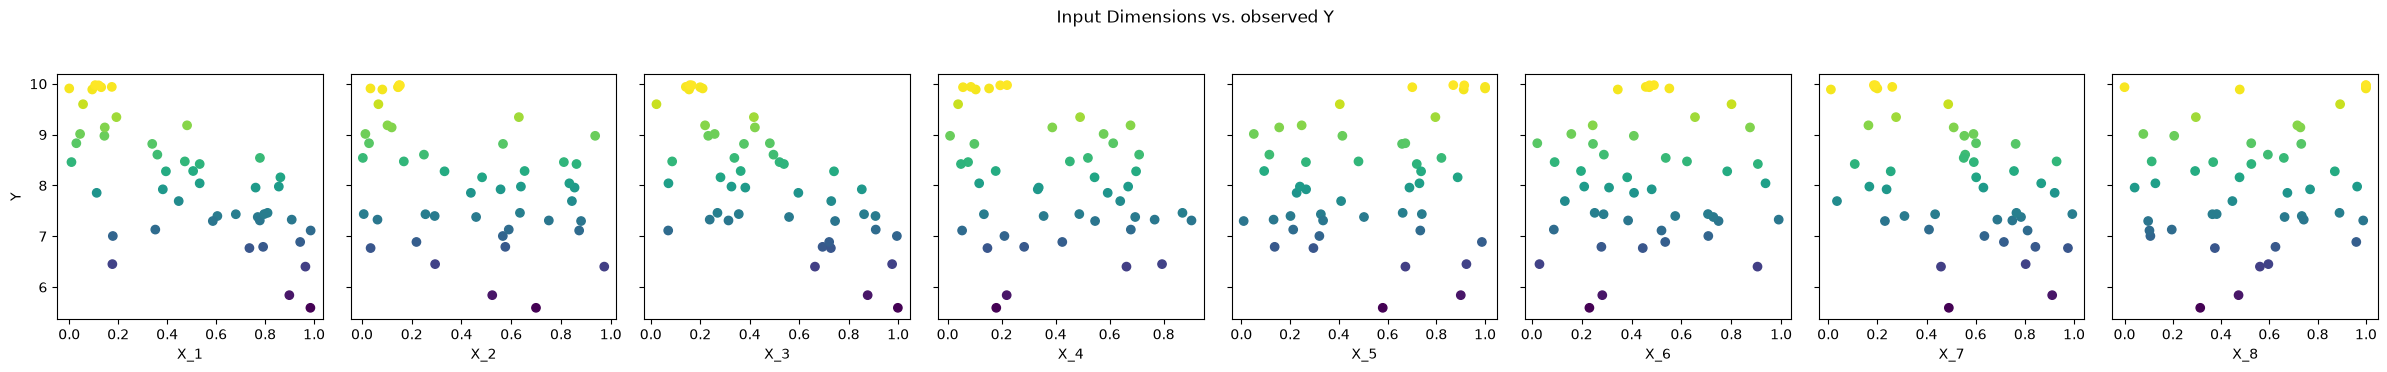

In [22]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6','X_7','X_8']):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

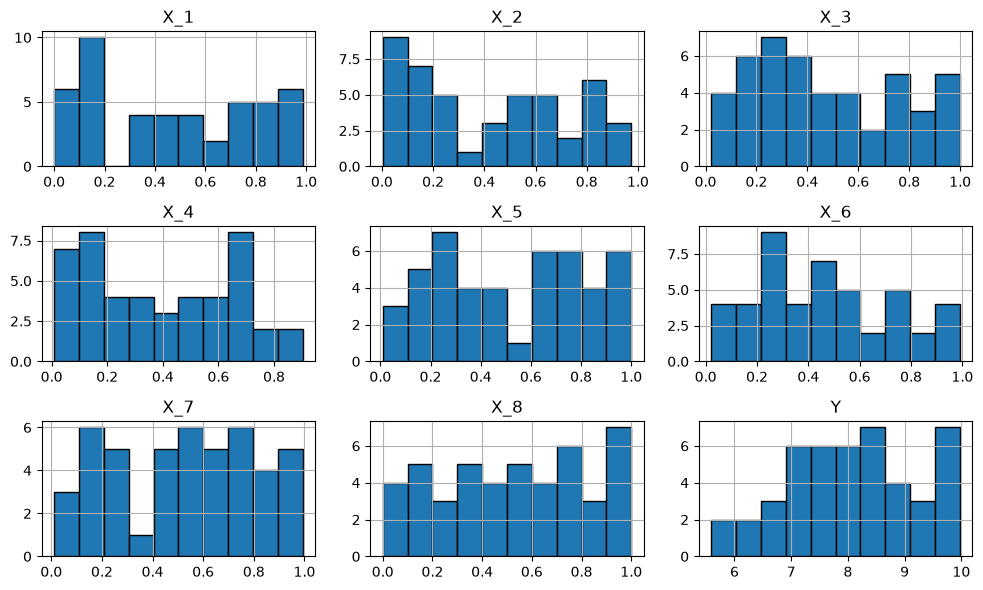

In [24]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [26]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6", 'X_7','X_8']
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.7168149082997854
 corr(X_2, Y) = -0.4104466130106405
 corr(X_3, Y) = -0.6981679461045724
 corr(X_4, Y) = -0.29023411927987747
 corr(X_5, Y) = 0.19061485768408734
 corr(X_6, Y) = 0.05602983432845486
 corr(X_7, Y) = -0.5053247068814215
 corr(X_8, Y) = 0.20345837774691772


<Axes: >

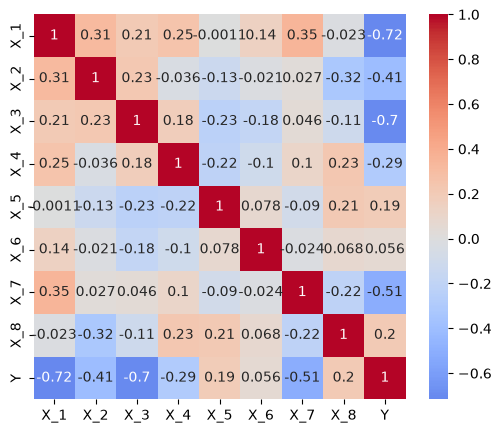

In [28]:
# Plotting the Correlation heatmap
plt.figure(figsize = (6,5))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

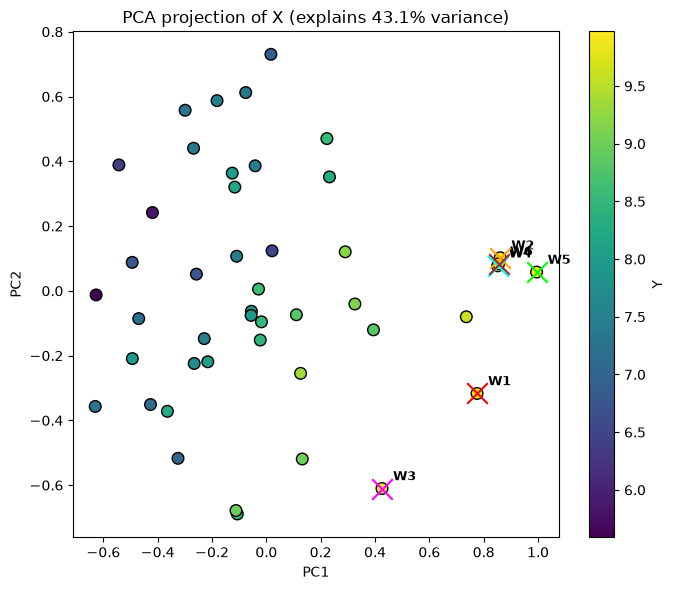

In [29]:
# Identify clustering of high-y points using PCA projection to 2D
pca            = PCA(n_components = 2)
X2             = pca.fit_transform(X)
fig, ax        = plt.subplots(figsize = (7, 6))

n_initial      = len(X0)
n_weeks_so_far = X.shape[0] - n_initial   
week_labels = np.array([0] * n_initial + list(range(1, n_weeks_so_far + 1)))

sc   = plt.scatter(X2[:, 0], X2[:, 1], c = Y, cmap = "viridis", s = 70, edgecolor = "k")

# Each week's query point: distinct marker/colour, annotated with its week number
markers = ["x", "x", "x", "x", "x", "x", "x", "x"]
colors  = ["red", "orange", "magenta", "cyan", "lime", "brown", "gold", "deepskyblue"]

for wk in range(1, n_weeks_so_far + 1):
    mask = week_labels == wk
    ax.scatter(X2[mask, 0], X2[mask, 1], c = colors[(wk - 1) % len(colors)], s = 220, edgecolor = "k", linewidth=1.5
               , marker = markers[(wk - 1) % len(markers)], label = f"Week {wk} query", zorder = 5)
    for xi, yi in zip(X2[mask, 0], X2[mask, 1]):
        ax.annotate(f"W{wk}", (xi, yi), textcoords = "offset points", xytext = (8, 6),
                    fontsize=9, fontweight = "bold")

plt.colorbar(sc, ax = ax, label = "Y")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
plt.tight_layout()
plt.show()

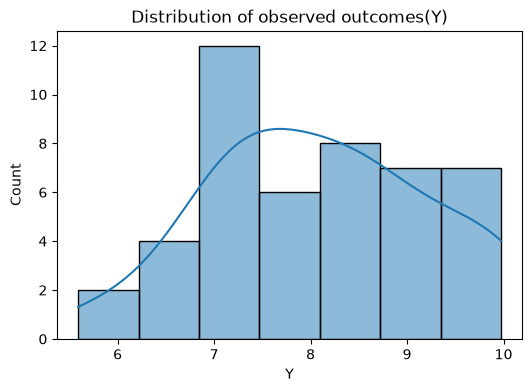

In [31]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [35]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-8, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [38]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.17**2 * RBF(length_scale=[1.75, 2.48, 1.35, 2.47, 3.82, 2.53, 1.85, 100]) + WhiteKernel(noise_level=1.51e-05)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [41]:
# Setting a higher beta(= 2.0) for Week -1
beta          = 2.0    # Week 1

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std   = gpr.predict(X_query, return_std = True)
    return mu + beta * std

n_points, n_dims = X.shape
rng_seed      = 42
n_candidates  = 10000
sampler       = qmc.LatinHypercube(d = n_dims, seed = rng_seed)
candidates    = sampler.random(n = n_candidates) 

ucb_values    = ucb(candidates, gpr, beta)
best_ucb_idx  = np.argmax(ucb_values)
next_point    = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.0367758  0.08940202 0.21038865 0.15722423 0.81773626 0.5591805
 0.10000647 0.84937986]
UCB Score: 9.952433e+00


# Week 2: Consolidated Bayesian Optimisation Function

In [45]:
def upper_confidence_bound(mu, sigma, beta = 2.0):
    """UCB(x) = mu(x) + beta * sigma(x). Higher beta => more exploration."""
    return mu + beta * sigma
    
def expected_improvement(mu, sigma, y_best, xi = 0.01):
    """EI(x) = E[max(f(x) - f(x_best) - xi, 0)]."""
    with np.errstate(divide = "warn"):
        improvement = mu - y_best - xi
        Z           = improvement / sigma
        ei          = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

def suggest_next_point( X_samples, y_samples, n_dims = 8, acquisition = "ucb", beta = 1.5,
                        xi = 0.01, n_restarts = 20, random_state = 42,
                        length_scale_bounds = (1e-2, 1e2), noise_bounds = (1e-8, 1e0)):

    rng    = np.random.default_rng(random_state)
    
    bounds = [(0.0, 0.999999)] * n_dims

    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(n_dims), length_scale_bounds = length_scale_bounds) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = noise_bounds)
   
    gp     = GaussianProcessRegressor(kernel = kernel, normalize_y = False, n_restarts_optimizer = 10, random_state = random_state)
    
    gp.fit(X_samples, y_samples)

    y_best = y_samples.max()

    def acq_objective(x):
        x         = x.reshape(1, -1)    
        mu, sigma = gp.predict(x, return_std=True)
        
        if acquisition == "ei":
            val   = expected_improvement(mu, sigma, y_best, xi = xi)
        else:
            val   = upper_confidence_bound(mu, sigma, beta = beta)
        
        return - val[0]  # minimise the negative -> maximise the acquisition

    best_val = np.inf
    X_next   = None
    for _ in range(n_restarts):
        x0   = rng.uniform(0, 0.999999, n_dims)
        res  = minimize(acq_objective, x0, bounds = bounds, method = "L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            X_next   = res.x

    mu_next, sigma_next = gp.predict(X_next.reshape(1, -1), return_std = True)
    return X_next, gp, mu_next[0], sigma_next[0], - best_val


In [47]:
beta    = 1.5

X_next, gp_week2, mu_next, sigma_next, acq_val = suggest_next_point(  X, Y, n_dims = 8, acquisition = "ucb", 
                                                                      beta = beta, n_restarts = 20, random_state = 42
                                                                    )

print(f"Week 2 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean  : {mu_next:.4f}")
print(f"Predicted std   : {sigma_next:.4f}")
print(f"UCB acquisition : {acq_val:.4f}  (beta = {beta})")

Week 2 next query point: [0.110144 0.138478 0.143852 0.214412 0.941978 0.489407 0.191806 0.      ]
Predicted mean  : 9.9597
Predicted std   : 0.0204
UCB acquisition : 9.9903  (beta = 1.5)


# Week 3: Get Query Point

In [50]:
# lowered beta from 1.5 to 1.0
beta_week3 = 1.0  

X_next, gp_week3, mu_next, sigma_next, acq_val = suggest_next_point(
    X, Y, n_dims = 8, acquisition = "ucb", beta = beta_week3, n_restarts = 20, random_state = 42
)

print(f"Week 3 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next:.4f}")
print(f"Predicted std          : {sigma_next:.4f}")
print(f"UCB acquisition        : {acq_val:.4f}  (beta = {beta_week3})")

Week 3 next query point: [0.10301  0.133894 0.162656 0.1635   0.830348 0.436881 0.201754 0.999999]
Predicted mean         : 9.9720
Predicted std          : 0.0094
UCB acquisition        : 9.9814  (beta = 1.0)


# Week 3: Perform Visualisation

In [53]:
# Identify the two most-correlated input dims (for slicing/plotting)
corrs      = np.array([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
top2       = np.argsort(-np.abs(corrs))[:2]
da, db     = int(top2[0]), int(top2[1])
print(f"Slicing through x{da+1} and x{db+1} (most correlated with Y)")

incumbent  = X[Y.argmax()].copy()

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week3.predict(pts, return_std=True)
Z_mean    = mu_grid.reshape(res_grid, res_grid)
Z_ucb     = (mu_grid + beta_week3 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x1 and x3 (most correlated with Y)


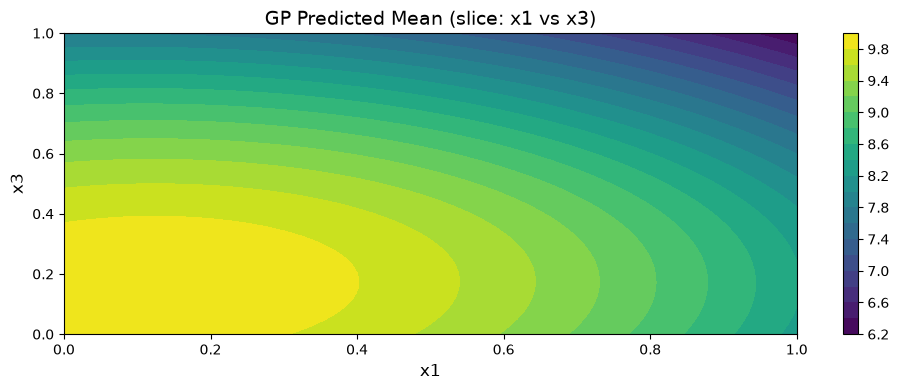

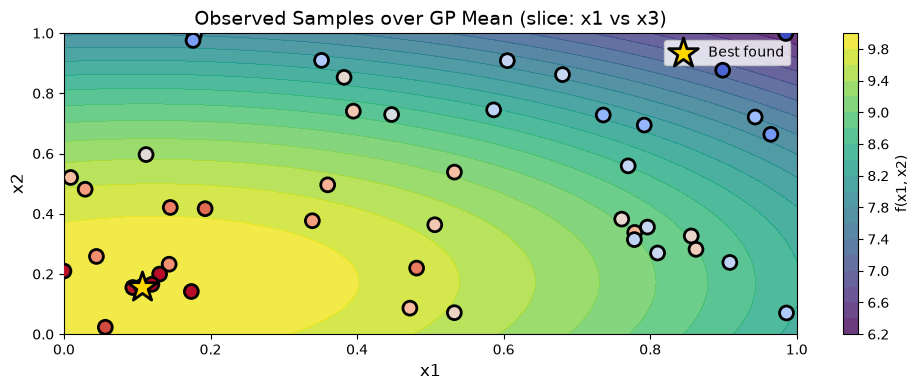

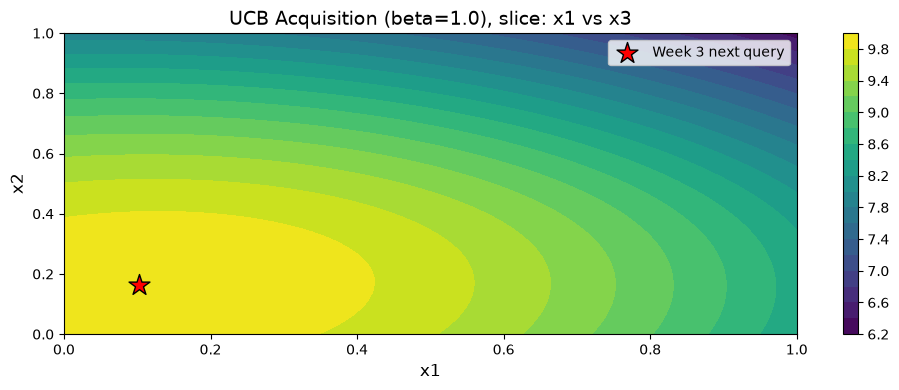

In [55]:
# GP predicted mean surface (using plotting_utils.plot_2d_function)
fig, ax = plot_2d_function(A, B, Z_mean, title=f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
plt.show()

# Observed samples overlaid on the GP mean surface (using plotting_utils.plot_2d_bo_state)
fig, ax = plot_2d_bo_state(A, B, Z_mean, X[:, [da, db]], Y,
                            title=f"Observed Samples over GP Mean (slice: x{da+1} vs x{db+1})")
plt.show()

# UCB acquisition surface with the Week 3 query point marked
fig, ax = plot_2d_function(A, B, Z_ucb, title=f"UCB Acquisition (beta={beta_week3}), slice: x{da+1} vs x{db+1}")
ax.scatter(X_next[da], X_next[db], marker="*", c="red", s=250, edgecolor="k", label="Week 3 next query")
ax.legend()
plt.show()

# Week 4: Calling the consolidated Bayesian Function with lowered β( = 0.7 )

In [58]:
beta_week4 = 0.7   # lowered from Week 3's 1.0 -- see rationale above

X_next, gp_week4, mu_next, sigma_next, acq_val = suggest_next_point(
    X, Y, n_dims=8, acquisition="ucb", beta=beta_week4, n_restarts=20, random_state=42
)

print(f"Week 4 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next:.4f}")
print(f"Predicted std          : {sigma_next:.4f}")
print(f"UCB acquisition        : {acq_val:.4f}  (beta = {beta_week4})")

Week 4 next query point: [0.107435 0.136115 0.162991 0.167776 0.84133  0.449731 0.198068 0.999999]
Predicted mean         : 9.9733
Predicted std          : 0.0078
UCB acquisition        : 9.9788  (beta = 0.7)


# Perform Visualisation

In [60]:
# Identify the two most-correlated input dims (for slicing/plotting)
corrs      = np.array([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
top2       = np.argsort(-np.abs(corrs))[:2]
da, db     = int(top2[0]), int(top2[1])
print(f"Slicing through x{da+1} and x{db+1} (most correlated with Y)")

incumbent  = X[Y.argmax()].copy()

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week4.predict(pts, return_std=True)
Z_mean    = mu_grid.reshape(res_grid, res_grid)
Z_ucb     = (mu_grid + beta_week4 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x1 and x3 (most correlated with Y)


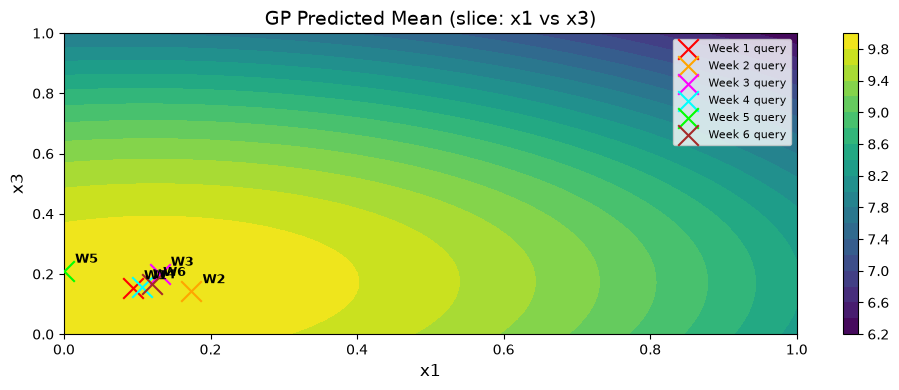

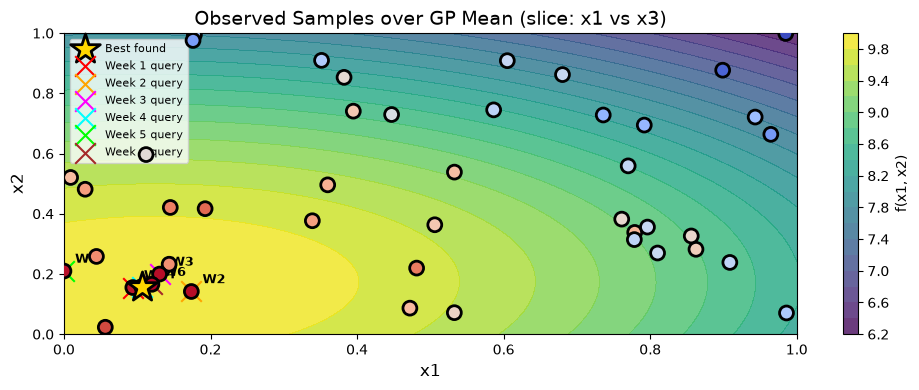

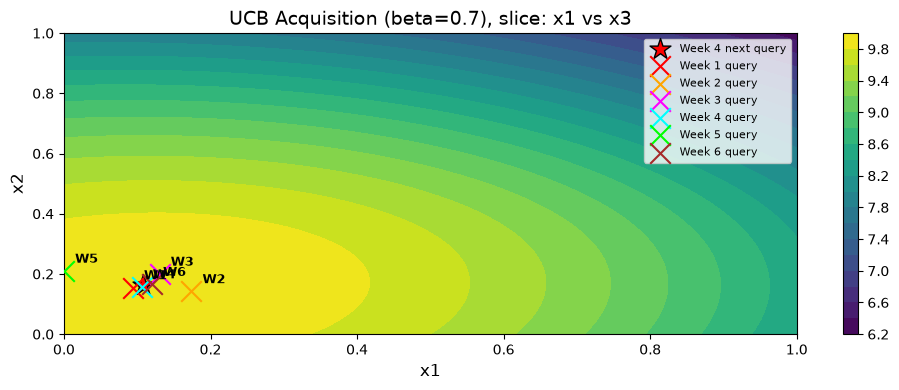

In [63]:
n_initial = len(X0)
n_weeks_so_far = X.shape[0] - n_initial   # e.g. 3 after Week 3 is appended
week_labels = np.array([0] * n_initial + list(range(1, n_weeks_so_far + 1)))

markers = ["x", "x", "x", "x", "x", "x", "x", "x"]
colors  = ["red", "orange", "magenta", "cyan", "lime", "brown", "gold", "deepskyblue"]

def highlight_weekly_points(ax, dim_a, dim_b):
    """Overlay each week's query point (columns dim_a, dim_b of X) on the given axes."""
    for wk in range(1, n_weeks_so_far + 1):
        mask = week_labels == wk
        ax.scatter(X[mask, dim_a], X[mask, dim_b], c=colors[(wk - 1) % len(colors)], s=220,
                   edgecolor="k", linewidth=1.5, marker=markers[(wk - 1) % len(markers)],
                   label=f"Week {wk} query", zorder=6)
        for xi, yi in zip(X[mask, dim_a], X[mask, dim_b]):
            ax.annotate(f"W{wk}", (xi, yi), textcoords="offset points", xytext=(8, 6),
                        fontsize=9, fontweight="bold", zorder=7)


# GP predicted mean surface (using plotting_utils.plot_2d_function)
fig, ax = plot_2d_function(A, B, Z_mean, title=f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

# Observed samples overlaid on the GP mean surface (using plotting_utils.plot_2d_bo_state)
fig, ax = plot_2d_bo_state(A, B, Z_mean, X[:, [da, db]], Y,
                            title=f"Observed Samples over GP Mean (slice: x{da+1} vs x{db+1})")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

# UCB acquisition surface with the Week 4 query point marked
fig, ax = plot_2d_function(A, B, Z_ucb, title=f"UCB Acquisition (beta={beta_week4}), slice: x{da+1} vs x{db+1}")
ax.scatter(X_next[da], X_next[db], marker="*", c="red", s=250, edgecolor="k", label="Week 4 next query")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

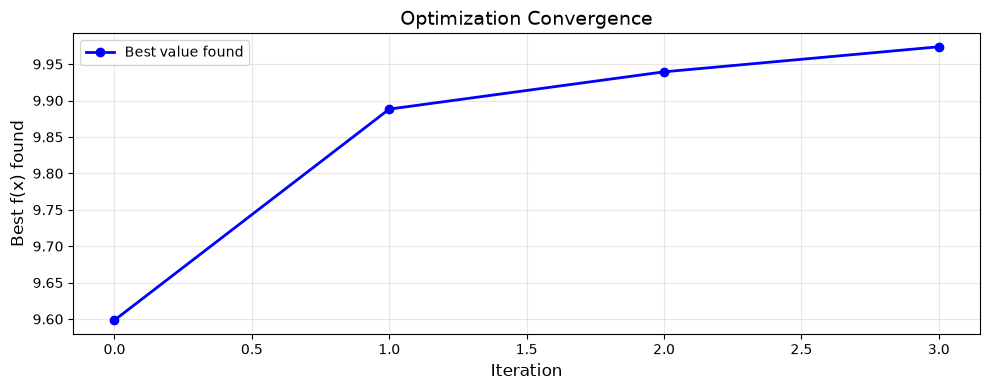

Best after Week 0 (initial data): 9.598482
Best after Week 1:                9.888207
Best after Week 2:                9.939383
Best after Week 3:                9.973776


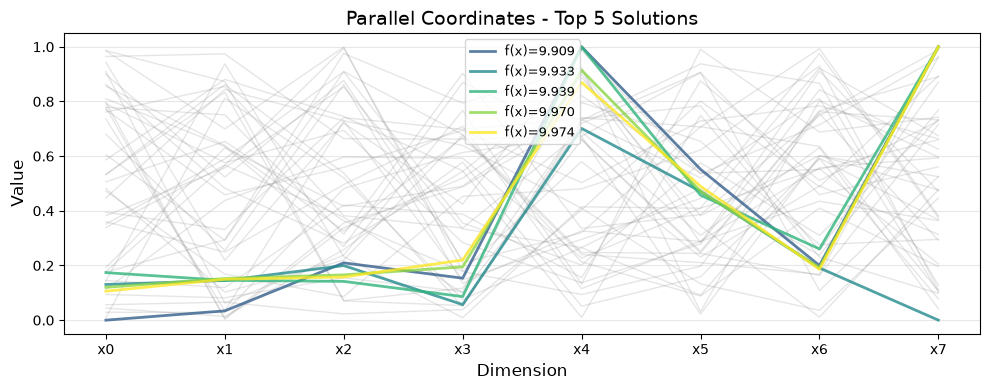

In [65]:
# Convergence: best value found at the end of each week
best_week0 = Y0.max()                                    # best of the original 40 points
best_week1 = max(best_week0, Y_w1_new_point[0])
best_week2 = max(best_week1, Y_w2_new_point[0])
best_week3 = Y.max()                                      # best after appending W1+W2+W3

plot_convergence([0, 1, 2, 3], [best_week0, best_week1, best_week2, best_week3])
plt.show()

print(f"Best after Week 0 (initial data): {best_week0:.6f}")
print(f"Best after Week 1:                {best_week1:.6f}")
print(f"Best after Week 2:                {best_week2:.6f}")
print(f"Best after Week 3:                {best_week3:.6f}")

# Parallel coordinates: how do the top 5 solutions compare across all 8 dimensions?
plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 5: Strategy Review
Weeks 1-4 followed a single monotone plan: keep lowering β (2.0 → 1.5 → 1.0 → 0.7) and let the GP exploit. Week 4 produced a new best (9.973776), so the natural next step would be β = 0.5. **The diagnostics below show that would be the wrong move.** 

In [68]:
from scipy.stats import qmc

probe          = qmc.LatinHypercube(d = 8, seed = 7).random(50000)
mu_probe, sg_probe = gpr.predict(probe, return_std = True)

print(f"Current best observed y      : {Y.max():.6f}")
print(f"Best GP-predicted mu anywhere: {mu_probe.max():.6f}")
print(f"Fraction of space where mu > y_best: {(mu_probe > Y.max()).mean():.5f}")
print()
_, sigma_at_incumbent = gpr.predict(X[Y.argmax()].reshape(1, -1), return_std = True)
print(f"GP sigma at the incumbent    : {sigma_at_incumbent[0]:.6f}")
print(f"Learned noise level          : {gpr.kernel_.k2.noise_level:.2e}")

Current best observed y      : 9.973776
Best GP-predicted mu anywhere: 9.940711
Fraction of space where mu > y_best: 0.00000

GP sigma at the incumbent    : 0.005102
Learned noise level          : 1.51e-05


In [70]:
# Checking how x8 contributes
ls_learned = gpr.kernel_.k1.k2.length_scale
print("ARD length scales (short = influential, long = irrelevant):")
for i in np.argsort(ls_learned):
    print(f"  x{i+1}: {ls_learned[i]:.3f}")

print("\nx8 across weekly queries so far:")
for wk, pt in enumerate([X_w1_new_point, X_w2_new_point, X_w3_new_point, X_w4_new_point], start = 1):
    print(f"  Week {wk}: x8 = {pt[7]:.6f}")

ARD length scales (short = influential, long = irrelevant):
  x3: 1.353
  x1: 1.754
  x7: 1.855
  x4: 2.469
  x2: 2.485
  x6: 2.526
  x5: 3.821
  x8: 100.000

x8 across weekly queries so far:
  Week 1: x8 = 0.477351
  Week 2: x8 = 0.999999
  Week 3: x8 = 0.000000
  Week 4: x8 = 0.999999


**Observations:**
1. **The surrogate has saturated.** The GP predicts that *nothing anywhere in the space* beats the current incumbent. Expected Improvement would therefore be identically zero everywhere, making EI unusable as an acquisition function this week. UCB with a small β simply re-samples within ~0.1 of the incumbent, i.e. it would spend a query confirming what the model already believes.
2. **That confidence is not trustworthy.** The learned noise level keeps collapsing to its lower bound and σ at the incumbent is ~1e-4, meaning the GP is *interpolating* 44 points rather than regularising them. A model this certain, on this little data in 8D, is over-confident - and Week 3 already gave us empirical proof (predicted 9.995, actual 9.933). So "nothing beats the incumbent" is an extrapolation from data that all sits in one corner of the space, not evidence.
3. **x8 is a nuisance dimension.** Its length scale has run away to the upper bound (~1e3): the GP detects *no* relationship between x8 and Y. The optimiser has been flip-flopping it between the extremes (0.477 → 0.999999 → 0.000000 → 0.999999) purely because the acquisition surface is flat along that axis. Worse, when we search for distinct local optima of the GP mean, the "different" optima returned are **identical in x1–x7 and differ only in x8**.

# Week 5: Strategy Change
| | Weeks 1-4 | Week 5 |
|---|---|---|
| β | 2.0 → 0.7 (monotone decrease) | **3.0** (deliberate increase) |
| x8 | free | **frozen** at the incumbent value |
| Noise floor | 1e-8 (collapses → interpolation) | **1e-4** (forces regularisation, restores honest σ) |
| Intent | exploitation | **one exploration probe** |

**Why raise β rather than lower it.** Exploitation is exhausted: The model has no signal pointing uphill. The capstone brief notes that one function has two optima, and we would have no way of knowing whether Function 8 is the one. If the probe returns a poor value we lose one query and have *confirmed* the basin, which is itself worth knowing. If it returns a high value we have found a second region with few weeks left to refine it.

**Why β = 3.0 and not higher.** A β sweep showed β ≤ 2.0 stays within 0.09 of the incumbent, while β = 8 lands on a point with predicted mean ≈ 8.95. β = 3.0 steps a meaningful distance away while keeping the predicted mean around 9.9, which would indicate a controlled probe.

In [74]:
kernel_week5 = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e3)) \
                 + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-4, 1e0))   # <-- floor raised

gp_week5 = GaussianProcessRegressor(kernel = kernel_week5, normalize_y = False,
                                     n_restarts_optimizer = 10, random_state = 42)
gp_week5.fit(X, Y)

print("Week 5 kernel:", gp_week5.kernel_)
_, s_new = gp_week5.predict(X[Y.argmax()].reshape(1, -1), return_std = True)
print(f"sigma at incumbent: {s_new[0]:.5f}   (was ~0.0001 with the 1e-8 floor)")

Week 5 kernel: 2.16**2 * RBF(length_scale=[1.74, 2.47, 1.35, 2.47, 3.92, 2.51, 1.86, 1e+03]) + WhiteKernel(noise_level=0.0001)
sigma at incumbent: 0.01262   (was ~0.0001 with the 1e-8 floor)


In [75]:
beta_week5 = 3.0                       # raised from Week 4's 0.7
incumbent5 = X[Y.argmax()].copy()
X8_FIXED   = incumbent5[7]             # freeze the nuisance dimension
REL_DIMS   = [0, 1, 2, 3, 4, 5, 6]     # x1..x7 carry the signal

# Global candidate pool over x1..x7, with x8 held fixed
lhs_7d     = qmc.LatinHypercube(d = 7, seed = 7).random(200000)
cand       = np.hstack([lhs_7d, np.full((len(lhs_7d), 1), X8_FIXED)])

mu_c, sg_c = gp_week5.predict(cand, return_std = True)
ucb_c      = mu_c + beta_week5 * sg_c
seed_pt    = cand[ucb_c.argmax()]

# Polish with L-BFGS-B, keeping x8 pinned
def neg_ucb_w5(x):
    x      = x.reshape(1, -1)
    m, s   = gp_week5.predict(x, return_std = True)
    return -(m + beta_week5 * s)[0]

bounds_w5  = [(0.0, 0.999999)] * 7 + [(X8_FIXED, X8_FIXED)]
res_w5     = minimize(neg_ucb_w5, seed_pt, bounds = bounds_w5, method = "L-BFGS-B")
X_next     = res_w5.x

mu_next, sigma_next = gp_week5.predict(X_next.reshape(1, -1), return_std = True)
dist_rel   = np.linalg.norm(X_next[REL_DIMS] - incumbent5[REL_DIMS])

print(f"Week 5 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next[0]:.4f}")
print(f"Predicted std          : {sigma_next[0]:.4f}   (vs ~0.01 for a greedy query)")
print(f"Distance from incumbent (x1-x7): {dist_rel:.3f}")
print(f"beta = {beta_week5}, x8 frozen at {X8_FIXED:.6f}")

Week 5 next query point: [0.14766  0.142099 0.129708 0.203361 0.93474  0.627848 0.118016 0.999999]
Predicted mean         : 9.9297
Predicted std          : 0.0301   (vs ~0.01 for a greedy query)
Distance from incumbent (x1-x7): 0.175
beta = 3.0, x8 frozen at 0.999999


# Week 5: Visualisation

In [77]:
ls5        = gp_week5.kernel_.k1.k2.length_scale
da, db     = np.argsort(ls5)[:2]                 # shortest length scales = most influential
da, db     = int(da), int(db)
print(f"Slicing through x{da+1} and x{db+1} (shortest ARD length scales)")

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent5, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week5.predict(pts, return_std = True)
Z_mean     = mu_grid.reshape(res_grid, res_grid)
Z_sigma    = sigma_grid.reshape(res_grid, res_grid)
Z_ucb      = (mu_grid + beta_week5 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x3 and x1 (shortest ARD length scales)


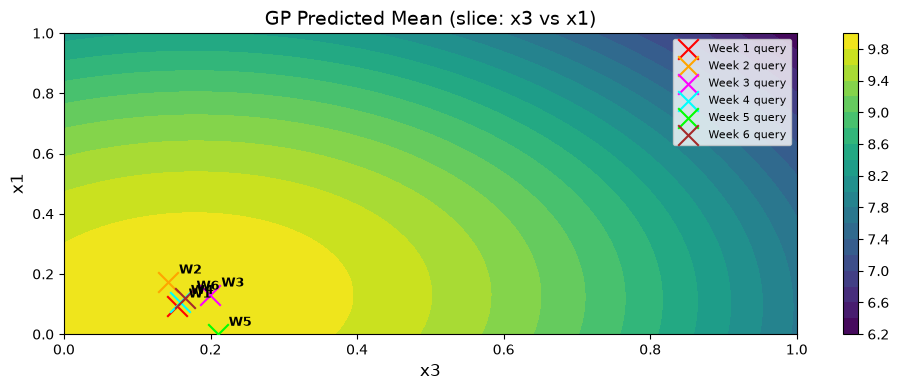

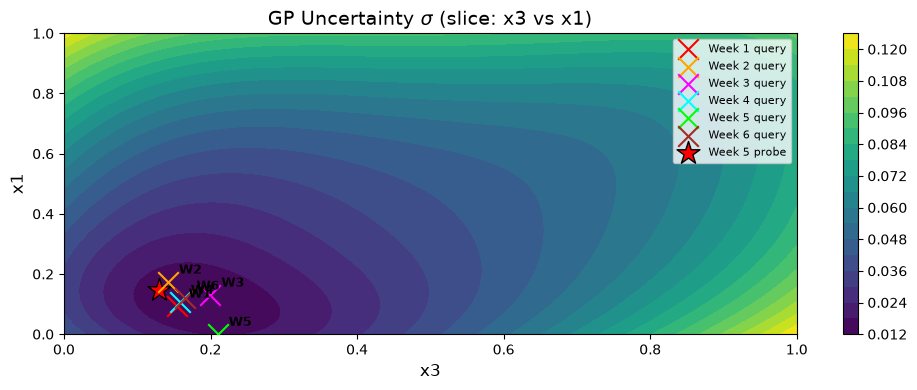

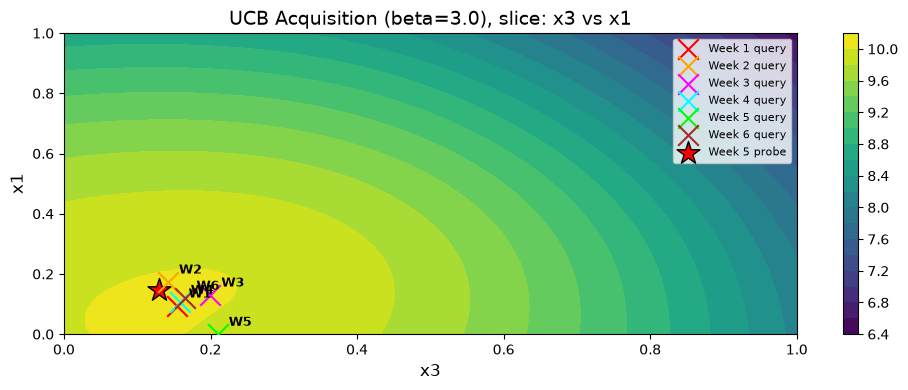

In [78]:
# GP mean
fig, ax = plot_2d_function(A, B, Z_mean, title = f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize = 8)
plt.show()

# Uncertainty surface -- shows WHERE the model is still ignorant (drives this week's probe)
fig, ax = plot_2d_function(A, B, Z_sigma, title = f"GP Uncertainty $\\sigma$ (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 5 probe")
ax.legend(fontsize = 8)
plt.show()

# UCB with the Week 5 probe marked
fig, ax = plot_2d_function(A, B, Z_ucb, title = f"UCB Acquisition (beta={beta_week5}), slice: x{da+1} vs x{db+1}")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 5 probe")
ax.legend(fontsize = 8)
plt.show()

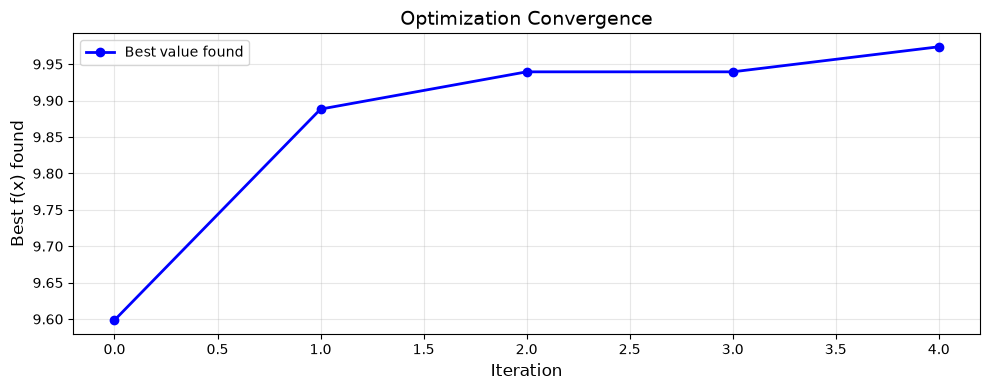

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776


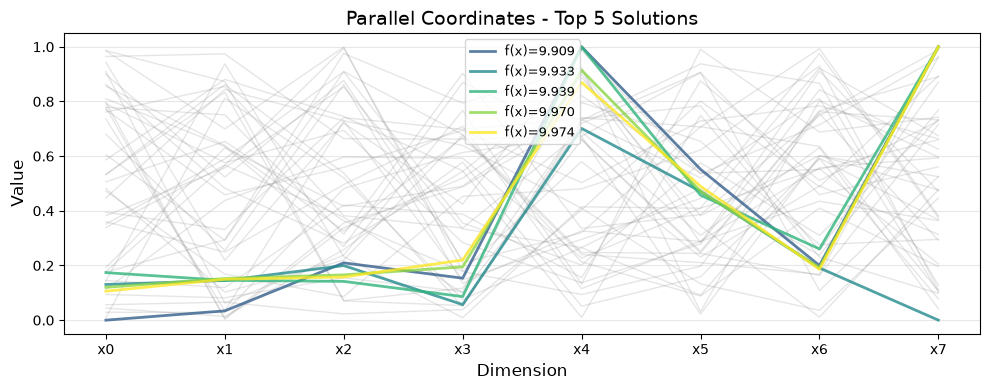

In [82]:
# Convergence
best_week0 = Y0.max()
best_week1 = max(best_week0, Y_w1_new_point[0])
best_week2 = max(best_week1, Y_w2_new_point[0])
best_week3 = max(best_week2, Y_w3_new_point[0])
best_week4 = max(best_week3, Y_w4_new_point[0])

plot_convergence([0, 1, 2, 3, 4], [best_week0, best_week1, best_week2, best_week3, best_week4])
plt.show()

for wk, v in enumerate([best_week0, best_week1, best_week2, best_week3, best_week4]):
    print(f"Best after Week {wk}: {v:.6f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

# Week 6: Strategy Review

In [86]:
# Determining the headroom left in the basin
kernel_week6 = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e3)) \
                 + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-4, 1e0))   # floor kept at 1e-4

gp_week6 = GaussianProcessRegressor(kernel = kernel_week6, normalize_y = False,
                                     n_restarts_optimizer = 10, random_state = 42)
gp_week6.fit(X, Y)
print("Week 6 kernel:", gp_week6.kernel_)

incumbent6 = X[Y.argmax()].copy()
X8_FIXED   = incumbent6[7]

# Scan the space (x8 frozen) and ask how much the model thinks is still available
scan       = np.hstack([qmc.LatinHypercube(d = 7, seed = 11).random(200000),
                        np.full((200000, 1), X8_FIXED)])
mu_s, sg_s = gp_week6.predict(scan, return_std = True)

print(f"\nBest observed y            : {Y.max():.6f}")
print(f"Best GP mean anywhere      : {mu_s.max():.6f}  ({mu_s.max() - Y.max():+.6f})")
print(f"Fraction with mu > y_best  : {(mu_s > Y.max()).mean():.6f}")
print(f"Fraction with UCB(0.5) > y_best : {((mu_s + 0.5 * sg_s) > Y.max()).mean():.6f}")

Week 6 kernel: 2.16**2 * RBF(length_scale=[1.74, 2.47, 1.35, 2.47, 3.92, 2.51, 1.86, 1e+03]) + WhiteKernel(noise_level=0.0001)

Best observed y            : 9.973776
Best GP mean anywhere      : 9.947130  (-0.026646)
Fraction with mu > y_best  : 0.000000
Fraction with UCB(0.5) > y_best : 0.000000


**Observation: The basin is a plateau, not a peak.** The GP's best predicted mean anywhere is *below* the value we already hold, and even an optimistic UCB(β = 0.5) bound clears the incumbent nowhere in 200,000 sampled points. Scanning individual dimensions through the incumbent shows why the surface is genuinely flat near the top (x5 moves 0.87 → 1.00 for a change of only 0.0025 in predicted mean; x4 is flat across 0.15 → 0.22).

This is the honest position going into the final weeks: **expected remaining gain in this basin is on the order of a few thousandths**, and the realistic upside comes from the model's residual uncertainty (σ ≈ 0.012) rather than from any predicted improvementHence, . Week poling would be more towards a refing thent que point.h.

In [88]:
beta_week6 = 0.5                       # was 3.0 in Week 5's probe
REL_DIMS   = [0, 1, 2, 3, 4, 5, 6]

ucb_scan   = mu_s + beta_week6 * sg_s
seed_pt    = scan[ucb_scan.argmax()]

def neg_ucb_w6(x):
    x    = x.reshape(1, -1)
    m, s = gp_week6.predict(x, return_std = True)
    return -(m + beta_week6 * s)[0]

bounds_w6  = [(0.0, 0.999999)] * 7 + [(X8_FIXED, X8_FIXED)]
res_w6     = minimize(neg_ucb_w6, seed_pt, bounds = bounds_w6, method = "L-BFGS-B")
X_next     = res_w6.x

mu_next, sigma_next = gp_week6.predict(X_next.reshape(1, -1), return_std = True)

print(f"Week 6 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next[0]:.4f}   (incumbent {Y.max():.4f}, so {mu_next[0]-Y.max():+.4f})")
print(f"Predicted std          : {sigma_next[0]:.4f}")
print(f"Distance from incumbent (x1-x7): {np.linalg.norm(X_next[REL_DIMS] - incumbent6[REL_DIMS]):.3f}")
print(f"beta = {beta_week6}, x8 frozen at {X8_FIXED:.6f}")

Week 6 next query point: [0.118696 0.149207 0.16628  0.187521 0.909783 0.471305 0.193476 0.999999]
Predicted mean         : 9.9735   (incumbent 9.9738, so -0.0002)
Predicted std          : 0.0115
Distance from incumbent (x1-x7): 0.058
beta = 0.5, x8 frozen at 0.999999


# Week 6: Visualisation

In [90]:
ls6        = gp_week6.kernel_.k1.k2.length_scale
da, db     = [int(v) for v in np.argsort(ls6)[:2]]
print(f"Slicing through x{da+1} and x{db+1} (shortest ARD length scales)")

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent6, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week6.predict(pts, return_std = True)
Z_mean     = mu_grid.reshape(res_grid, res_grid)
Z_sigma    = sigma_grid.reshape(res_grid, res_grid)
Z_ucb      = (mu_grid + beta_week6 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x3 and x1 (shortest ARD length scales)


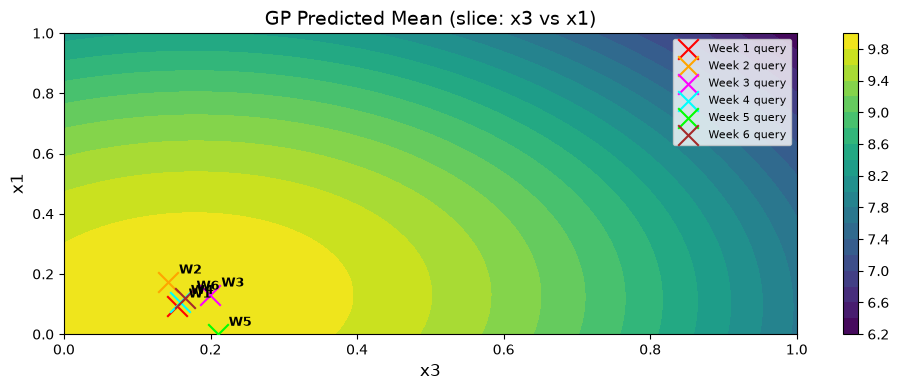

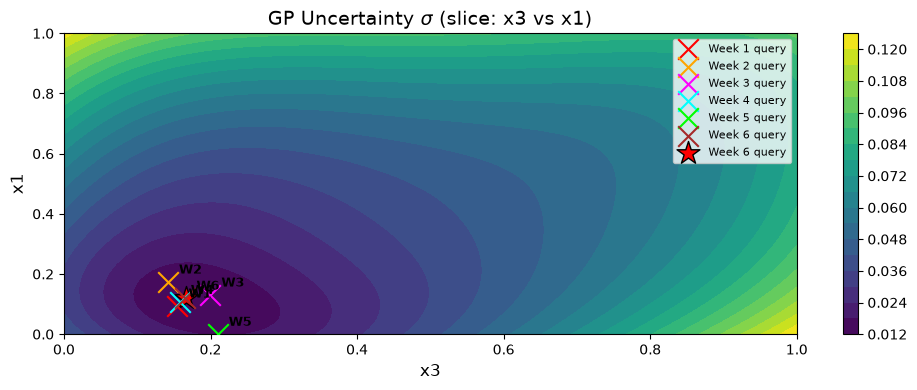

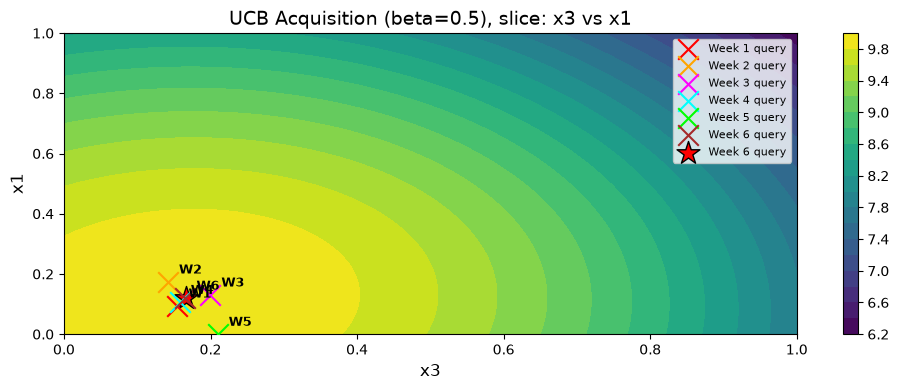

In [92]:
fig, ax = plot_2d_function(A, B, Z_mean, title = f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize = 8); plt.show()

fig, ax = plot_2d_function(A, B, Z_sigma, title = f"GP Uncertainty $\\sigma$ (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 6 query")
ax.legend(fontsize = 8); plt.show()

fig, ax = plot_2d_function(A, B, Z_ucb, title = f"UCB Acquisition (beta={beta_week6}), slice: x{da+1} vs x{db+1}")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 6 query")
ax.legend(fontsize = 8); plt.show()

Week  Pred      Sigma    Actual      Error      z       Inside 1σ?
3     9.9950    0.0320   9.933047    -0.0620    -1.94   NO
4     9.9810    0.0210   9.973776    -0.0072    -0.34   yes
5     9.9170    0.0460   9.908828    -0.0082    -0.18   yes

Week 3 ran with the 1e-8 noise floor; Weeks 4-5 with regularisation applied.


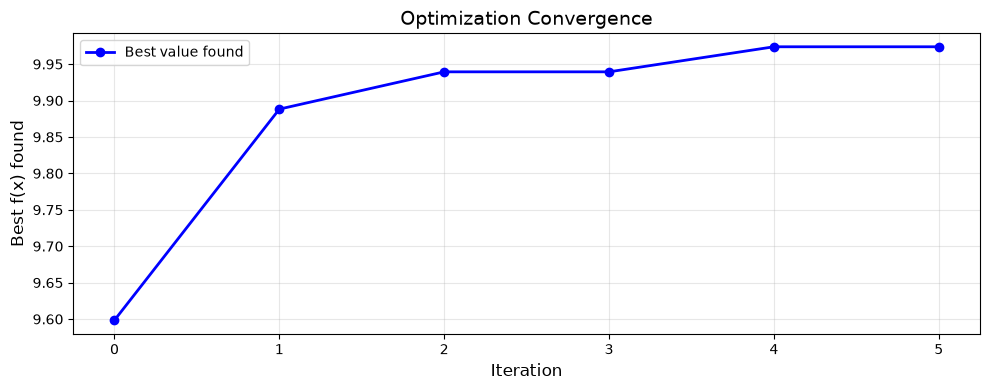

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776
Best after Week 5: 9.973776


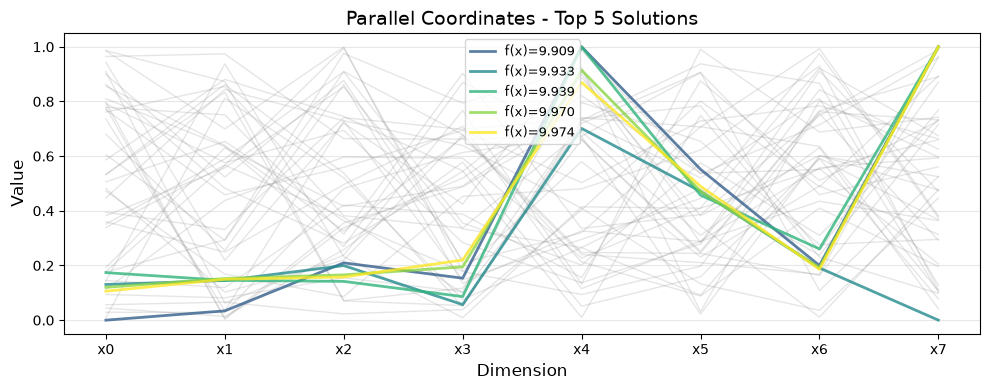

In [95]:
calib = [
    # week, predicted mu, predicted sigma, actual
    (3, 9.9950, 0.0320, 9.933047259977),
    (4, 9.9810, 0.0210, 9.9737756546419),
    (5, 9.9170, 0.0460, 9.9088278236074),
]
print(f"{'Week':<6}{'Pred':<10}{'Sigma':<9}{'Actual':<12}{'Error':<11}{'z':<8}Inside 1σ?")
for wk, m_, s_, a_ in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<6}{m_:<10.4f}{s_:<9.4f}{a_:<12.6f}{err:<+11.4f}{z:<+8.2f}{'yes' if abs(z) <= 1 else 'NO'}")

print("\nWeek 3 ran with the 1e-8 noise floor; Weeks 4-5 with regularisation applied.")

# Convergence including Weeks 4 and 5
best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0],
           Y_w4_new_point[0], Y_w5_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.6f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

# Week 7: Strategy Review( Hyperparameter Tuning )

In [101]:
# Week 7: Systematic GP hyperparameter tuning Grid over {kernel family} x {noise floor}, scored by leave-one-out CV.
# LOO is the right criterion here: log-marginal-likelihood measures in-sample fit, but what we actually need is out-of-sample 
# prediction at an unseen point.

from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import LeaveOneOut

def build_kernel(family, noise_floor, nu = 2.5):
    base = RBF(np.ones(8), (1e-2, 1e3)) if family == "rbf" \
           else Matern(np.ones(8), (1e-2, 1e3), nu = nu)
    return ConstantKernel(1.0, (1e-2, 1e2)) * base + WhiteKernel(1e-2, (noise_floor, 1e0))

def loo_score(kernel, n_restarts = 3):
    """Leave-one-out RMSE plus calibration diagnostics."""
    sq_err, z_scores = [], []
    for tr, te in LeaveOneOut().split(X):
        g    = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts,
                                         random_state = 42).fit(X[tr], Y[tr])
        m, s = g.predict(X[te], return_std = True)
        sq_err.append((m[0] - Y[te][0]) ** 2)
        z_scores.append((Y[te][0] - m[0]) / s[0])
    z = np.array(z_scores)
    return np.sqrt(np.mean(sq_err)), np.mean(np.abs(z) <= 1), np.std(z)

print(f"{'config':<26}{'LML':<10}{'LOO-RMSE':<11}{'cover68':<10}{'z-std'}")
print("-" * 66)
for family, nu in [("rbf", None), ("matern", 1.5), ("matern", 2.5)]:
    for nf in [1e-8, 1e-4, 1e-3]:
        kern  = build_kernel(family, nf, nu if nu else 2.5)
        g     = GaussianProcessRegressor(kernel = kern, n_restarts_optimizer = 10,
                                          random_state = 42).fit(X, Y)
        lml   = g.log_marginal_likelihood(g.kernel_.theta)
        rmse, cover, zstd = loo_score(kern)
        label = f"{family}{'' if nu is None else nu} nf={nf:g}"
        print(f"{label:<26}{lml:<10.3f}{rmse:<11.4f}{cover:<10.2f}{zstd:.2f}")

print("\nIdeal calibration: cover68 = 0.68, z-std = 1.00")

config                    LML       LOO-RMSE   cover68   z-std
------------------------------------------------------------------
rbf nf=1e-08              21.669    0.0683     0.61      1.15
rbf nf=0.0001             21.061    0.0653     0.74      0.91
rbf nf=0.001              17.609    0.0709     0.80      0.81
matern1.5 nf=1e-08        9.126     0.1290     0.65      1.00
matern1.5 nf=0.0001       8.554     0.1307     0.63      1.02
matern1.5 nf=0.001        6.867     0.1377     0.61      1.01
matern2.5 nf=1e-08        18.196    0.0589     0.85      0.65
matern2.5 nf=0.0001       16.878    0.0629     0.78      0.67
matern2.5 nf=0.001        13.874    0.0756     0.76      0.73

Ideal calibration: cover68 = 0.68, z-std = 1.00


**Observations:**

**Matern(ν=2.5) with a 1e-8 noise floor gives the best out-of-sample accuracy**: LOO-RMSE **0.0589** against **0.0653** for the incumbent RBF configuration is roughly 10% better, and identical across four random seeds, so it is not a seeding artefact.

**The two criteria disagree.** RBF has the higher log-marginal-likelihood (21.06 vs 18.20), so on in-sample evidence RBF wins. Matern wins on leave-one-out error. These measure different things: LML rewards fitting the 46 points we have; LOO rewards predicting a point we have *not* seen. Since the entire purpose of the surrogate is to predict at an unvisited location, LOO is the criterion that matches the task, and that is why the kernel is being switched.

**Neither model is perfectly calibrated.** Matdrn's coverage is 0.85 against an ideal of 0.68, with z-std 0.65. It is *under-confident*, producing intervals that are too wide. RBF at 1e-4 sits closer to ideal (0.74 coverage, z-std 0.91). So the switch trades slightly worse-calibrated uncertainty for meaningfully better mean prediction. Under-confidence is the safer direction of the two errors.

**Why Matern fits better.** Matern(ν=2.5) assumes a rougher, less infinitely-smooth surface than RBF. Its longer fitted length-scales (x3: 2.77 vs 1.35) mean it reads the data as a broader, flatter ridge rather than a sharp peak, which matches the plateau behaviour Weeks 5 and 6 both alluded to.

In [111]:
# Checking if freezing x8 is still the right call
gp_matern = GaussianProcessRegressor(kernel = build_kernel("matern", 1e-8, 2.5),
                                      n_restarts_optimizer = 10, random_state = 42).fit(X, Y)
print("Matern kernel:", gp_matern.kernel_)
ls_m = gp_matern.kernel_.k1.k2.length_scale
print("\nARD length scales:")
for i in np.argsort(ls_m):
    print(f"  x{i+1}: {ls_m[i]:.2f}")

incumbent7 = X[Y.argmax()].copy()
X8_FIXED   = incumbent7[7]

# Search with x8 FREE and compare against x8 frozen
free_scan       = qmc.LatinHypercube(d = 8, seed = 5).random(150000)
mu_f, sg_f      = gp_matern.predict(free_scan, return_std = True)
print(f"\nBest UCB(0.5) with x8 free : mu = {mu_f[(mu_f + 0.5*sg_f).argmax()]:.5f}")
print(f"x8 length scale            : {ls_m[7]:.1f}  (still pinned at the bound)")
print("=> x8 carries no signal even under the better kernel; the freeze stands.")

Matern kernel: 3.36**2 * Matern(length_scale=[3.49, 4.89, 2.77, 5.23, 7.88, 5.07, 3.66, 1e+03], nu=2.5) + WhiteKernel(noise_level=1e-08)

ARD length scales:
  x3: 2.77
  x1: 3.49
  x7: 3.66
  x2: 4.89
  x6: 5.07
  x4: 5.23
  x5: 7.88
  x8: 1000.00

Best UCB(0.5) with x8 free : mu = 9.96646
x8 length scale            : 1000.0  (still pinned at the bound)
=> x8 carries no signal even under the better kernel; the freeze stands.


In [113]:
# Week 7: Calling the returned surrogate
beta_week7 = 0.5
REL_DIMS   = [0, 1, 2, 3, 4, 5, 6]

scan7      = np.hstack([qmc.LatinHypercube(d = 7, seed = 3).random(150000),
                        np.full((150000, 1), X8_FIXED)])
mu7, sg7   = gp_matern.predict(scan7, return_std = True)

print(f"Best observed y           : {Y.max():.6f}")
print(f"Best Matern mean anywhere : {mu7.max():.6f}  ({mu7.max() - Y.max():+.6f})")

seed_pt7   = scan7[(mu7 + beta_week7 * sg7).argmax()]

def neg_ucb_w7(x):
    x    = x.reshape(1, -1)
    m, s = gp_matern.predict(x, return_std = True)
    return -(m + beta_week7 * s)[0]

bounds_w7  = [(0.0, 0.999999)] * 7 + [(X8_FIXED, X8_FIXED)]
res_w7     = minimize(neg_ucb_w7, seed_pt7, bounds = bounds_w7, method = "L-BFGS-B")
X_next     = res_w7.x

mu_next, sigma_next = gp_matern.predict(X_next.reshape(1, -1), return_std = True)

print(f"\nWeek 7 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next[0]:.5f}   (incumbent {Y.max():.5f}, {mu_next[0]-Y.max():+.5f})")
print(f"Predicted std          : {sigma_next[0]:.5f}")
print(f"Distance from incumbent (x1-x7): {np.linalg.norm(X_next[REL_DIMS] - incumbent7[REL_DIMS]):.3f}")

Best observed y           : 9.973776
Best Matern mean anywhere : 9.941640  (-0.032135)

Week 7 next query point: [0.090448 0.191056 0.103416 0.186342 0.910161 0.573338 0.158195 0.999999]
Predicted mean         : 9.97975   (incumbent 9.97378, +0.00597)
Predicted std          : 0.02062
Distance from incumbent (x1-x7): 0.124


# Week 7: Visualisation

Slicing through x3 and x1 (shortest ARD length scales)


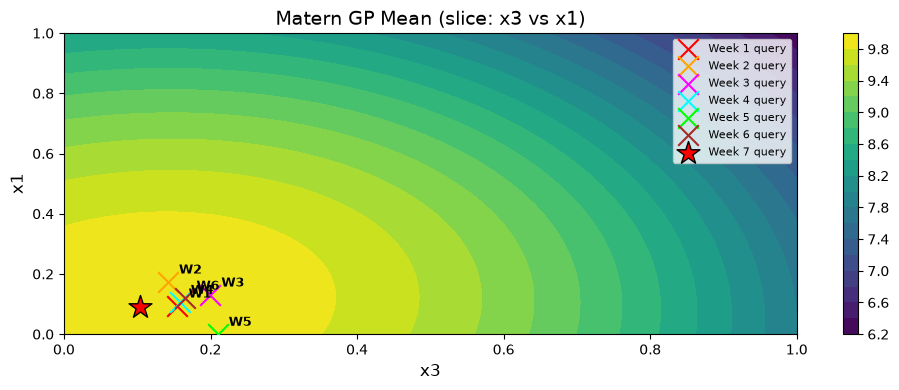

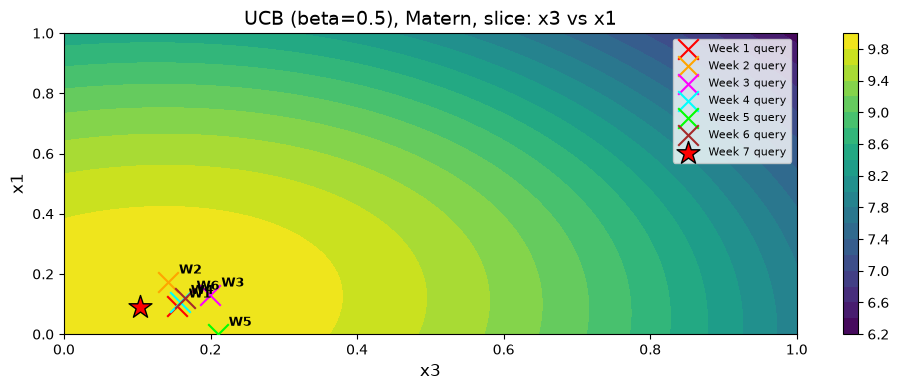

In [116]:
ls7        = gp_matern.kernel_.k1.k2.length_scale
da, db     = [int(v) for v in np.argsort(ls7)[:2]]
print(f"Slicing through x{da+1} and x{db+1} (shortest ARD length scales)")

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent7, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_matern.predict(pts, return_std = True)
Z_mean     = mu_grid.reshape(res_grid, res_grid)
Z_sigma    = sigma_grid.reshape(res_grid, res_grid)
Z_ucb      = (mu_grid + beta_week7 * sigma_grid).reshape(res_grid, res_grid)

fig, ax = plot_2d_function(A, B, Z_mean, title = f"Matern GP Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 7 query")
ax.legend(fontsize = 8); plt.show()

fig, ax = plot_2d_function(A, B, Z_ucb, title = f"UCB (beta={beta_week7}), Matern, slice: x{da+1} vs x{db+1}")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 7 query")
ax.legend(fontsize = 8); plt.show()

Wk  Pred      Sigma    Actual      Error      z       1σ?   Config
3   9.9950    0.0320   9.933047    -0.0620    -1.94   NO    RBF, noise floor 1e-8
4   9.9810    0.0210   9.973776    -0.0072    -0.34   yes   RBF, noise floor 1e-8
5   9.9170    0.0460   9.908828    -0.0082    -0.18   yes   RBF, noise floor 1e-4
6   9.9754    0.0125   9.969918    -0.0055    -0.44   yes   RBF, noise floor 1e-4

Three consecutive calibrated weeks since the noise floor was raised.


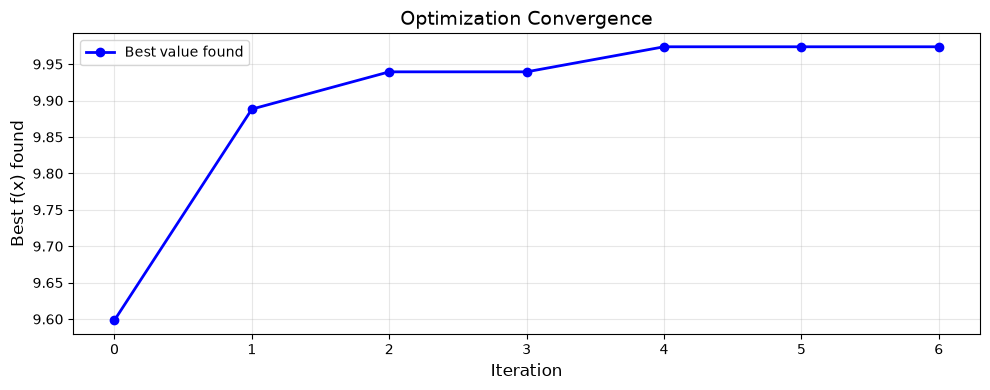

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776
Best after Week 5: 9.973776
Best after Week 6: 9.973776


In [118]:
# Week 7: calibration tracking, now including Week 6
calib = [
    (3, 9.9950, 0.0320, 9.933047259977,  "RBF, noise floor 1e-8"),
    (4, 9.9810, 0.0210, 9.9737756546419, "RBF, noise floor 1e-8"),
    (5, 9.9170, 0.0460, 9.9088278236074, "RBF, noise floor 1e-4"),
    (6, 9.9754, 0.0125, 9.9699176427994, "RBF, noise floor 1e-4"),
]
print(f"{'Wk':<4}{'Pred':<10}{'Sigma':<9}{'Actual':<12}{'Error':<11}{'z':<8}{'1σ?':<6}Config")
for wk, m_, s_, a_, cfg in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<4}{m_:<10.4f}{s_:<9.4f}{a_:<12.6f}{err:<+11.4f}{z:<+8.2f}{'yes' if abs(z)<=1 else 'NO':<6}{cfg}")
print("\nThree consecutive calibrated weeks since the noise floor was raised.")

best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0],
           Y_w4_new_point[0], Y_w5_new_point[0], Y_w6_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.6f}")

# Portal Submission 

In [120]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(X_next)
print("Points to be submitted(Week 1):",'0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351')
print("Points to be submitted(Week 2):",'0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999')
print("Points to be submitted(Week 3):", '0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000')
print("Points to be submitted(Week 4):", '0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999')
print("Points to be submitted(Week 5):", '0.000000-0.034040-0.209666-0.153509-0.999999-0.551705-0.199997-0.999999')
print("Points to be submitted(Week 6):", '0.120036-0.152437-0.165666-0.194783-0.914473-0.472016-0.192359-0.999999')
print(f"Points to be submitted(Week 7): {submission_str}")

Points to be submitted(Week 1): 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351
Points to be submitted(Week 2): 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999
Points to be submitted(Week 3): 0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000
Points to be submitted(Week 4): 0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999
Points to be submitted(Week 5): 0.000000-0.034040-0.209666-0.153509-0.999999-0.551705-0.199997-0.999999
Points to be submitted(Week 6): 0.120036-0.152437-0.165666-0.194783-0.914473-0.472016-0.192359-0.999999
Points to be submitted(Week 7): 0.090448-0.191056-0.103416-0.186342-0.910161-0.573338-0.158195-0.999999
